In [ ]:
#lab20
print("group members")
print("\nZakira Abdurahman")
print("\nIlham Mustefa")

group members

Zakira Abdurahman

Ilham Mustefa


In [ ]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split 
from sklearn.preprocessing import StandardScaler, LabelEncoder 
from sklearn.linear_model import LinearRegression
from sklearn.metrics import ( 
mean_squared_error,
mean_absolute_error,
r2_score
)


In [3]:
#Part 1: Data Exploration
# Task 1 load the dataset
df = pd.read_csv("oil_sales_assignment_data.csv")
print("Dataset loaded successfully!")

df.head()


Dataset loaded successfully!


,city,store_name,manufacturer,brand,class,size,sku,price_bracket,year,month,value_sales,volume_sales,average_price
0,AL BAHA,HM No 57296 GS-CENTER-AL BAHA MAIN RD AL BAHA,NOVA FOODS,LARA,COCONUT,0.75L,LARA COCONUT 0.75L TWIN PACK,21-30,2024,12,830.86,30.1,27.6
1,AL KHARJ,HM No 55697 GS-CENTER-AL KHARJ MAIN RD AL K...,PALM & GRAIN GROUP,NAJMA,CANOLA,0.5L,NAJMA CANOLA 0.5L TWIN PACK,41-50,2024,10,373.10,9.1,41.0
2,RIYADH,HM No 86781 GS-CENTER-RIYADH MAIN RD RIYADH,AL HILAL INDUSTRIES,BAYTNA,SUNFLOWER,0.75L,BAYTNA SUNFLOWER 0.75L ECO,101+,2023,1,171.70,1.7,101.0
3,DAMMAM,HM No 95753 GS-CENTER-DAMMAM MAIN RD DAMMAM,PALM & GRAIN GROUP,NOUR,CORN,0.6L,NOUR CORN 0.6L TWIN PACK,61-70,2022,2,1226.10,20.1,61.0
4,JAZAN,HM No 56338 GS-CENTER-JAZAN MAIN RD JAZAN,DESERT SUN CO,NOUR,VEGETABLE,1L,NOUR VEGETABLE 1L,81-90,2024,2,996.30,12.3,81.0


In [4]:

df.tail()



,city,store_name,manufacturer,brand,class,size,sku,price_bracket,year,month,value_sales,volume_sales,average_price
1995,TABUK,HM No 99317 GS-CENTER-TABUK MAIN RD TABUK,NAJDI CONSUMER,LARA,COCONUT,0.5L,LARA COCONUT 0.5L PREMIUM,31-40,2024,11,74.4,2.4,31.0
1996,AL AHSA,HM No 85390 GS-CENTER-AL AHSA MAIN RD AL AHSA,BLUE OASIS CO,LARA,SUNFLOWER,3L,LARA SUNFLOWER 3L,31-40,2022,5,20.0,0.5,40.0
1997,AL KHARJ,HM No 90740 GS-CENTER-AL KHARJ MAIN RD AL K...,NOVA FOODS,NOUR,SUNFLOWER,2.9L,NOUR SUNFLOWER 2.9L,91-100,2023,8,527.8,5.8,91.0
1998,RIYADH,HM No 52893 GS-CENTER-RIYADH MAIN RD RIYADH,NOVA FOODS,NAJMA,CORN,0.75L,NAJMA CORN 0.75L ECO,61-70,2024,6,305.0,5.0,61.0
1999,JEDDAH,HM No 73689 GS-CENTER-JEDDAH MAIN RD JEDDAH,NAJDI CONSUMER,BAYTNA,COCONUT,1.8L,BAYTNA COCONUT 1.8L ECO,101+,2022,4,181.8,1.8,101.0


In [5]:
#task 2 
print("1 number of Rows:", df.shape[0])
print("2 number of Columns:", df.shape[1])

numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns

print("3 numerical Columns:")
print(list(numerical_columns))

categorical_columns = df.select_dtypes(include=['object', 'string']).columns
print("4categorical Columns:")
print(list(categorical_columns))


1 number of Rows: 2000
2 number of Columns: 13
3 numerical Columns:
['year', 'month', 'value_sales', 'volume_sales', 'average_price']
4categorical Columns:
['city', 'store_name', 'manufacturer', 'brand', 'class', 'size', 'sku', 'price_bracket']


In [6]:
# task 3 check for missing values
print("missing values:", df.isnull().sum())
print("total missing :", df.isnull().sum().sum())

missing values: city             0
store_name       0
manufacturer     0
brand            0
class            0
size             0
sku              0
price_bracket    0
year             0
month            0
value_sales      0
volume_sales     0
average_price    0
dtype: int64
total missing : 0


In [7]:
# task4 generate descriptive statistics
df.describe(include='all')

,city,store_name,manufacturer,brand,class,size,sku,price_bracket,year,month,value_sales,volume_sales,average_price
count,2000,2000,2000,2000,2000,2000,2000,2000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
unique,12,1997,8,10,5,13,1571,10,NaN,NaN,NaN,NaN,NaN
top,AL BAHA,HM No 59035 GS-CENTER-AL AHSA MAIN RD AL AHSA,AL HILAL INDUSTRIES,HILAL,SUNFLOWER,1L,GULF GOLD COCONUT 3L TWIN PACK,21-30,NaN,NaN,NaN,NaN,NaN
freq,199,2,272,223,424,178,5,222,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2022.990500,6.639500,614.839355,9.972100,60.990230
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.820211,3.468942,750.794991,9.862369,29.457029
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2022.000000,1.000000,6.960000,0.500000,11.000000
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2022.000000,4.000000,132.000000,2.900000,37.337500
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2023.000000,7.000000,368.320000,7.000000,61.000000
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024.000000,10.000000,794.100000,13.800000,81.000000


In [8]:
#part2 data Preparation, Label Encoding Categorical Variables

le = LabelEncoder()
categorical_cols = [
    'city',
    'store_name',
    'manufacturer',
    'brand',
    'class',
    'size',
    'sku',
    'price_bracket'
]

for col in categorical_cols:
    df[col + '_encoded'] = le.fit_transform(df[col])

print("Encoding completed successfully!")
df.head()




Encoding completed successfully!


,city,store_name,manufacturer,brand,class,size,sku,price_bracket,year,month,...,volume_sales,average_price,city_encoded,store_name_encoded,manufacturer_encoded,brand_encoded,class_encoded,size_encoded,sku_encoded,price_bracket_encoded
0,AL BAHA,HM No 57296 GS-CENTER-AL BAHA MAIN RD AL BAHA,NOVA FOODS,LARA,COCONUT,0.75L,LARA COCONUT 0.75L TWIN PACK,21-30,2024,12,...,30.1,27.6,1,302,5,3,1,3,537,2
1,AL KHARJ,HM No 55697 GS-CENTER-AL KHARJ MAIN RD AL K...,PALM & GRAIN GROUP,NAJMA,CANOLA,0.5L,NAJMA CANOLA 0.5L TWIN PACK,41-50,2024,10,...,9.1,41.0,2,237,6,4,0,1,648,4
2,RIYADH,HM No 86781 GS-CENTER-RIYADH MAIN RD RIYADH,AL HILAL INDUSTRIES,BAYTNA,SUNFLOWER,0.75L,BAYTNA SUNFLOWER 0.75L ECO,101+,2023,1,...,1.7,101.0,8,1487,0,0,3,3,93,0
3,DAMMAM,HM No 95753 GS-CENTER-DAMMAM MAIN RD DAMMAM,PALM & GRAIN GROUP,NOUR,CORN,0.6L,NOUR CORN 0.6L TWIN PACK,61-70,2022,2,...,20.1,61.0,3,1832,6,5,2,2,864,6
4,JAZAN,HM No 56338 GS-CENTER-JAZAN MAIN RD JAZAN,DESERT SUN CO,NOUR,VEGETABLE,1L,NOUR VEGETABLE 1L,81-90,2024,2,...,12.3,81.0,5,258,3,5,4,7,944,8


In [9]:
# part3 Univariate Linear Regression
#task 1
X_univariate = df[['average_price']]
y = df['value_sales']

print("Feature shape:", X_univariate.shape)
print("Target shape:", y.shape)



Feature shape: (2000, 1)
Target shape: (2000,)


In [10]:
# task 2 split the dataset to 80% Training and 20% testing
X_train_uni, X_test_uni, y_train, y_test = train_test_split(
    X_univariate,  y,
    test_size=0.2,
    random_state=42
)

print(f"Training set size: {X_train_uni.shape[0]}")
print(f"Test set size: {X_test_uni.shape[0]}")



Training set size: 1600
Test set size: 400


In [11]:
#task3 train a linear regression model 
uni_model = LinearRegression()

uni_model.fit( X_train_uni,  y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[10.51]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['average_price']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-27.28
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [12]:
#task4 regression equation:- Sales = b0 + b1 × Average Price
b0 = uni_model.intercept_
b1 = uni_model.coef_[0]

print("Intercept (b0):", b0)
print("Coefficient (b1):", b1)

print(f"Regreesion Equation:")
print(f"Value Sales = {b0:.2f} + ({b1:.2f} × Average Price)")

Intercept (b0): -27.28059154165237
Coefficient (b1): 10.507909773662433
Regreesion Equation:
Value Sales = -27.28 + (10.51 × Average Price)


In [13]:
#task5 Interpret Coefficient 
if b1> 0:
    print(
        f"When average price increases by 1 unit,"
        f"value sales increase by {b1:.2f} units."
    )
else:
    print(
        f"when average price increase by 1 unit,"
        f"value sales decrease by {abs(b1):.2f} units."
    )

When average price increases by 1 unit,value sales increase by 10.51 units.


In [14]:
# Task 6: Model Evaluation
y_pred_uni = uni_model.predict(X_test_uni)
rmse_uni = np.sqrt(mean_squared_error(y_test, y_pred_uni))
r2_uni = r2_score(y_test, y_pred_uni)

print("RMSE:", rmse_uni)
print("R2 Score:", r2_uni)

RMSE: 674.0336191200048
R2 Score: 0.13802212065425412


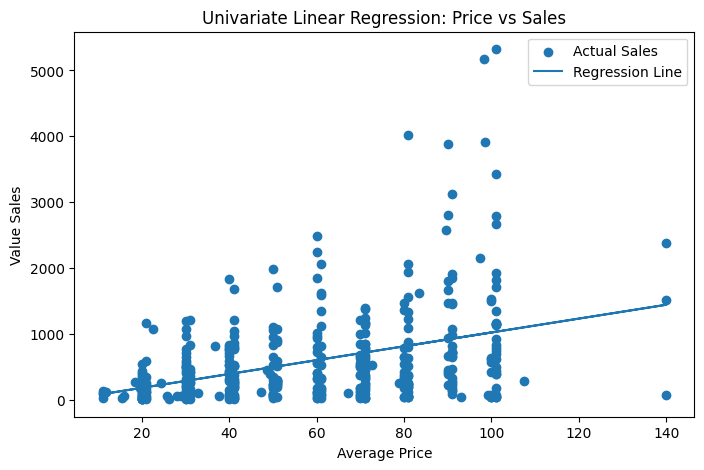

In [15]:
# task 7 visualization, Scatter Plot + Regression Line

plt.figure(figsize=(8,5))

# actual values
plt.scatter(
    X_test_uni,
    y_test,
    label="Actual Sales"
)

#regression line
plt.plot(
    X_test_uni,
    y_pred_uni,
    label="Regression Line"
)

plt.xlabel("Average Price")
plt.ylabel("Value Sales")
plt.title("Univariate Linear Regression: Price vs Sales")

plt.legend()
plt.show()

In [16]:
#Part 4: Multivariate Linear Regression
#task 1 Prepare the feature matrix

X_multi = df[
    [
        'average_price',
        'volume_sales',
        'year',
        'month',
        'city_encoded',
        'manufacturer_encoded',
        'brand_encoded',
        'class_encoded',
        'price_bracket_encoded'
    ]
]

y = df['value_sales']

print("feature Matrix Shape:", X_multi.shape)
print("Target Shape:", y.shape)


feature Matrix Shape: (2000, 9)
Target Shape: (2000,)


In [17]:
# task 2 Split the dataset
X_train_multi, X_test_multi, y_train, y_test = train_test_split(
    X_multi,
    y,
    test_size=0.2,
    random_state=42
)

print("Training set:", X_train_multi.shape)
print("Testing set:", X_test_multi.shape)

Training set: (1600, 9)
Testing set: (400, 9)


In [18]:
# task 3 standardize the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_multi)
X_test_scaled = scaler.transform(X_test_multi)

In [19]:
# Task4 train the model

multi_model = LinearRegression()
multi_model.fit(X_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](9,)","[295.37,626.82, 0.43,..., 1.81, -6.11, -9.36]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,617.1
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,9
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(9)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](9,)","[46.26,42.27,41.06,...,38.93,38.4 ,32.78]"


In [20]:
# task5 display the intercept

print("Intercept:", multi_model.intercept_)

Intercept: 617.1289937499998


In [22]:
# Task6 display coefficients

coef_df = pd.DataFrame({
    'Feature': X_multi.columns,
    'Coefficient': multi_model.coef_
})

coef_df['Absolute Coefficient'] = coef_df['Coefficient'].abs()

coef_df = coef_df.sort_values(
    by='Absolute Coefficient',
    ascending=False
)

print(coef_df)

                 Feature  Coefficient  Absolute Coefficient
1           volume_sales   626.818419            626.818419
0          average_price   295.369425            295.369425
4           city_encoded    10.495241             10.495241
8  price_bracket_encoded    -9.361265              9.361265
3                  month    -8.327633              8.327633
7          class_encoded    -6.106760              6.106760
5   manufacturer_encoded     2.810432              2.810432
6          brand_encoded     1.813375              1.813375
2                   year     0.426157              0.426157


In [23]:
# task7 evaluate the model

y_pred_multi = multi_model.predict(X_test_scaled)
rmse_multi = np.sqrt(mean_squared_error(y_test, y_pred_multi))
r2_multi = r2_score(y_test, y_pred_multi)

print("RMSE:", rmse_multi)
print("R2 Score:", r2_multi)

RMSE: 296.4672826865719
R2 Score: 0.8332420493793089


In [24]:
# Part 5: Model Comparison
#comparison table.
comparison_df = pd.DataFrame({
    'Model': ['Univariate', 'Multivariate'],
    'RMSE': [rmse_uni, rmse_multi],
    'R2 Score': [r2_uni, r2_multi]
})

print(comparison_df)

          Model        RMSE  R2 Score
0    Univariate  674.033619  0.138022
1  Multivariate  296.467283  0.833242


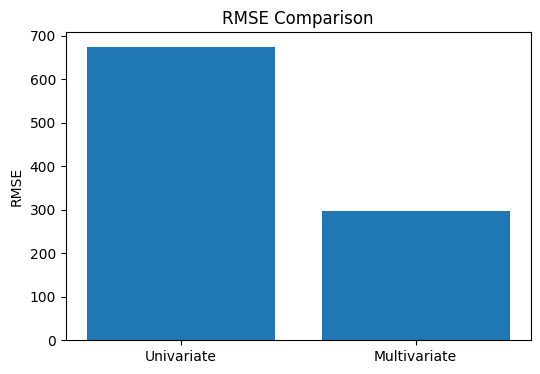

In [25]:
#Chart 1 Compare RMSE

plt.figure(figsize=(6,4))
plt.bar(comparison_df['Model'], comparison_df['RMSE'])
plt.title("RMSE Comparison")
plt.ylabel("RMSE")
plt.show()

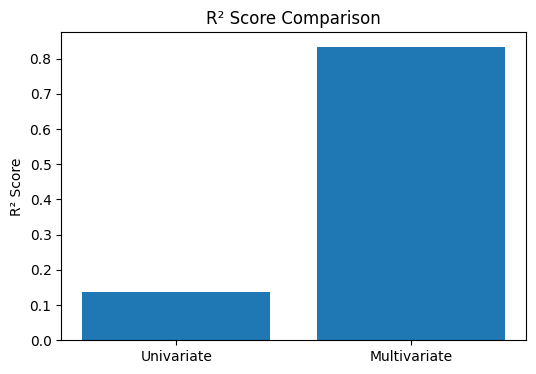

In [26]:
#chart 2 compare R² Score

plt.figure(figsize=(6,4))
plt.bar(comparison_df['Model'], comparison_df['R2 Score'])
plt.title("R² Score Comparison")
plt.ylabel("R² Score")
plt.show()


In [27]:
# part 6 Interpretation Questions


print("PART 6: INTERPRETATION QUESTIONS")

print("\nQuestion 1: Which model performed better? Why?")
print("Answer:")
print("The Multivariate Linear Regression model performed better because")
print(f"it achieved a lower RMSE ({rmse_multi:.2f}) and a higher R² score ({r2_multi:.3f})")
print(f"than the Univariate model (RMSE = {rmse_uni:.2f}, R² = {r2_uni:.3f}).")
print("This means it made more accurate predictions and explained more of the variation in Value Sales.")



print("\nQuestion 2: Why is the Multivariate model expected to perform better?")
print("Answer:")
print("The Multivariate model uses multiple features such as average price,")
print("volume sales, year, month, city, manufacturer, brand, class,")
print("and price bracket. Since sales are affected by many factors,")
print("using more relevant features improves prediction accuracy.")



top_feature = coef_df.iloc[0]

print("\nQuestion 3: Which feature appears to have the greatest influence on sales?")
print("Answer:")
print(f"The feature '{top_feature['Feature']}' has the largest absolute coefficient")
print(f"({top_feature['Absolute Coefficient']:.2f}), indicating that it has")
print("the greatest influence on Value Sales.")



print("\nQuestion 4: What does a negative coefficient mean?")
print("Answer:")
print("A negative coefficient means that as the value of that feature")
print("increases, the predicted Value Sales decreases while the other")
print("features remain constant.")



print("\nQuestion 5: If the R² score is 0.82, what does this tell us?")
print("Answer:")
print("An R² score of 0.82 means the model explains about 82% of the")
print("variation in Value Sales, indicating that it fits the data well.")



print("\nQuestion 6: Why should we evaluate the model using the test set instead of the training set?")
print("Answer:")
print("The test set contains unseen data, so it provides a fair evaluation")
print("of how well the model performs on new data. Evaluating only on the")
print("training set may give overly optimistic results because the model")
print("has already learned from that data.")





PART 6: INTERPRETATION QUESTIONS

Question 1: Which model performed better? Why?
Answer:
The Multivariate Linear Regression model performed better because
it achieved a lower RMSE (296.47) and a higher R² score (0.833)
than the Univariate model (RMSE = 674.03, R² = 0.138).
This means it made more accurate predictions and explained more of the variation in Value Sales.

Question 2: Why is the Multivariate model expected to perform better?
Answer:
The Multivariate model uses multiple features such as average price,
volume sales, year, month, city, manufacturer, brand, class,
and price bracket. Since sales are affected by many factors,
using more relevant features improves prediction accuracy.

Question 3: Which feature appears to have the greatest influence on sales?
Answer:
The feature 'volume_sales' has the largest absolute coefficient
(626.82), indicating that it has
the greatest influence on Value Sales.

Question 4: What does a negative coefficient mean?
Answer:
A negative coefficie